# ***TCGA数据挖掘***
----
> SNV分析

In [71]:
rm(list = ls())
options(stringsAsFactors = FALSE)
getwd()

[1] "/Users/luye/Library/Mobile Documents/com~apple~CloudDocs/Projects/Done/TCGA"

In [72]:
### Load packages
library(dplyr)
library(tidyverse)
library(ggplot2)
library(data.table)
library(maftools)

## **1-maftools基本绘图**

In [73]:
project = "TARGET-OS"
GENE = "CD24"
load(file = paste0("./0-Data/",project,"_maf.rda"))
clinical <- read.csv(file = paste0("./2-Output/",project,"_",GENE,"_expression.csv"), header = TRUE, stringsAsFactors = FALSE)
ls()

[1] "GENE"      "clinical"  "maf_merge" "project"

In [74]:
## 根据给定基因的表达值对样本进行分组，然后识别在两组样本之间差异表达的基因，最后用这些差异表达基因来进行功能富集
median_val <- median(clinical$Gene, na.rm = TRUE)  # 计算中位数,忽略缺失值
clinical$Group <- ifelse(clinical$Gene > median_val, "High", "Low")  # 创建新列group
clinical$Group <- factor(clinical$Group, levels = c("Low", "High"))  # 设置分组顺序

In [75]:
# 计算生存时间
clinical$days_to_death[clinical$days_to_death=="NA"] <- 0   #缺失值标记为0
clinical$days_to_death[is.na(clinical$days_to_death)] <- 0
clinical$days_to_last_follow_up[clinical$days_to_last_follow_up=="NA"] <- 0
clinical$days_to_last_follow_up[is.na(clinical$days_to_last_follow_up)] <- 0
clinical$days = as.numeric(clinical$days_to_death) + as.numeric(clinical$days_to_last_follow_up)
clinical$days

[1]  537  724    0    0  180    0    0  627  776    0  510    0    0    0  519
[16]    0    0    0  758    0    0    0  857    0 2882    0    0  347    0    0
[31]   74    0    0    0    0 3976    0    0    0    0    0    0    0  295    0
[46]    0    0 1906    0    0  679    0  754  922  603  271 1631 1003    0    0
[61]    0 1579    0    0    0    0  290    0  386    0    0    0    0    0    0
[76]    0  422 1515    0    0  653  619    0 1061    0    0    0    0

In [76]:
# 假设有一个名为 df 的数据框
colnames(clinical)[colnames(clinical) == "sample"] <- "Tumor_Sample_Barcode"

In [78]:
maf_df <- as.data.frame(maf_merge)
maf_df$Tumor_Sample_Barcode <- sapply(maf_df$Tumor_Sample_Barcode, function(x) {
  parts <- strsplit(x, "-")[[1]]
  prefix <- paste(parts[1:4], collapse="-")
  return(prefix)
})
maf_df <- maf_df[maf_df$Tumor_Sample_Barcode %in% clinical$Tumor_Sample_Barcode,]

In [79]:
maf_obj <- read.maf(maf = maf_df, clinicalData = clinical, isTCGA = FALSE)

-Validating
--Removed 30 duplicated variants
-Silent variants: 1149 
-Summarizing
--Possible FLAGS among top ten genes:
  MUC16
  TTN
-Processing clinical data
-Finished in 0.086s elapsed (0.084s cpu) 


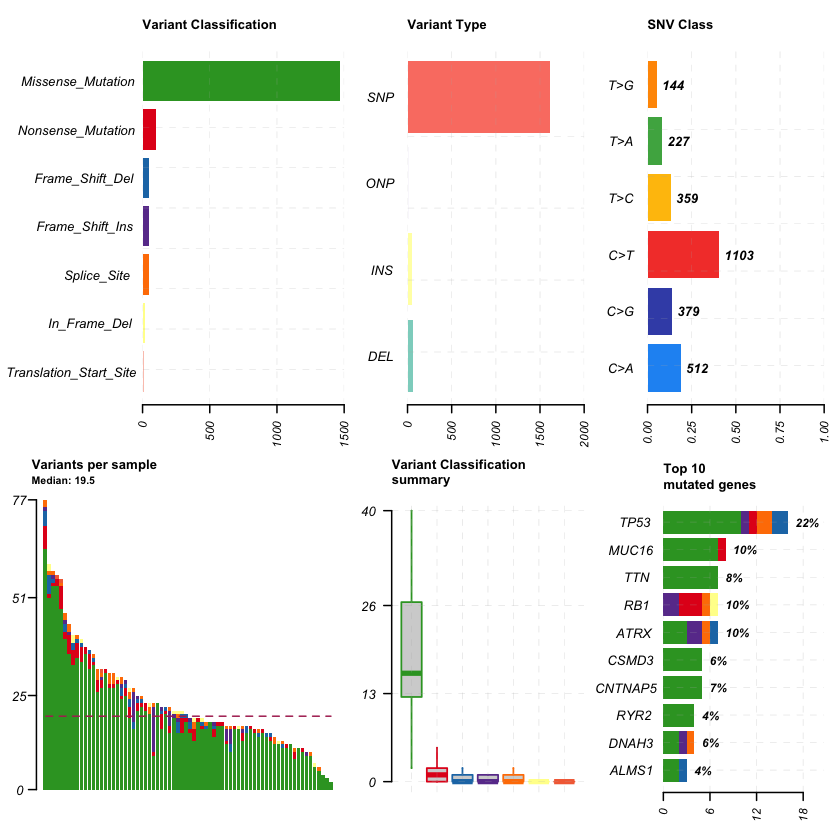

In [80]:
plotmafSummary(maf = maf_obj,
               rmOutlier = TRUE,
               addStat = "median",
               dashboard = TRUE,
               titvRaw = FALSE)

### 基因瀑布图

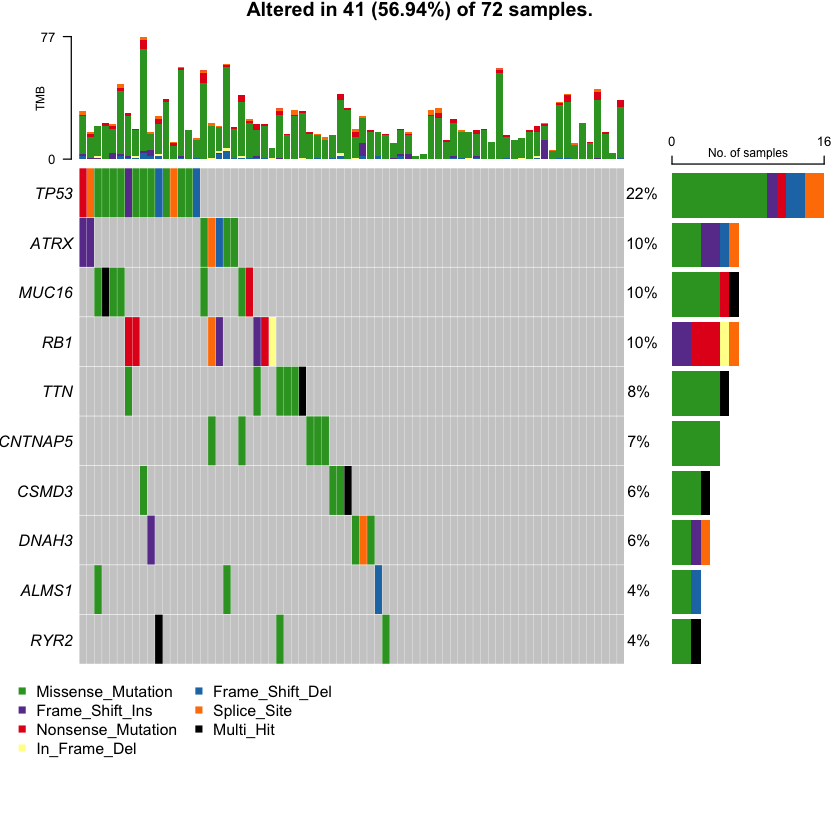

In [82]:
oncoplot(maf = maf_obj, top = 10)  # 如下图

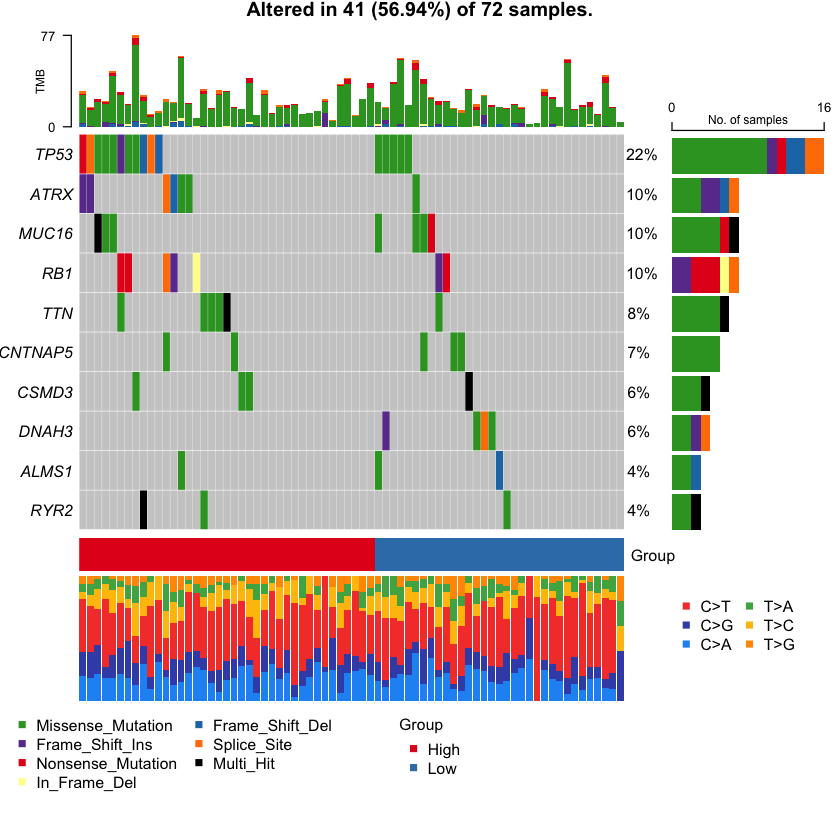

In [90]:
## 添加临床注释
oncoplot(maf = maf_obj, top = 10,
	  	 clinicalFeatures = "Group",
		 sortByAnnotation=T,
	  	 draw_titv = TRUE)

In [92]:
df=as.data.frame(maf_obj@data)
cg=as.character(maf_obj@clinical.data$Tumor_Sample_Barcode)[maf_obj@clinical.data$Group=='Low']
cg
s1.maf <- read.maf(df[df$Tumor_Sample_Barcode %in% cg, ])

cg=as.character(maf_obj@clinical.data$Tumor_Sample_Barcode)[maf_obj@clinical.data$Group=='High']
cg
s2.maf <- read.maf(df[df$Tumor_Sample_Barcode %in% cg, ])


[1] "TARGET-40-PALWWX-01A" "TARGET-40-PASYUK-01A" "TARGET-40-PATUXZ-01A"
 [4] "TARGET-40-0A4I0Q-01A" "TARGET-40-0A4HLD-01A" "TARGET-40-0A4I0W-01A"
 [7] "TARGET-40-PAMEKS-01A" "TARGET-40-PASUUH-01A" "TARGET-40-PAMJXS-01A"
[10] "TARGET-40-PANXSC-01A" "TARGET-40-PAMHYN-01A" "TARGET-40-0A4I3S-01A"
[13] "TARGET-40-PALHRL-01A" "TARGET-40-PANVJJ-01A" "TARGET-40-0A4I8U-01A"
[16] "TARGET-40-0A4I6O-01A" "TARGET-40-PATJVI-01A" "TARGET-40-PAPIJR-01A"
[19] "TARGET-40-PAPNVD-01A" "TARGET-40-PANSEN-01A" "TARGET-40-PAKUZU-01A"
[22] "TARGET-40-0A4I5B-01A" "TARGET-40-PASFCV-01A" "TARGET-40-0A4HY5-01A"
[25] "TARGET-40-PATMIF-01A" "TARGET-40-PATEEM-01A" "TARGET-40-PATAWV-01A"
[28] "TARGET-40-PAPXGT-01A" "TARGET-40-PAPWWC-01A" "TARGET-40-PAKZZK-01A"
[31] "TARGET-40-PANZZJ-01A" "TARGET-40-PASEBY-01A" "TARGET-40-PAKXLD-01A"

-Validating
-Summarizing
--Possible FLAGS among top ten genes:
  MUC16
-Processing clinical data
--Missing clinical data
-Finished in 0.046s elapsed (0.044s cpu) 


[1] "TARGET-40-PAMLKS-01A" "TARGET-40-0A4I4E-01A" "TARGET-40-0A4I48-01A"
 [4] "TARGET-40-0A4I4O-01A" "TARGET-40-PANMIG-01A" "TARGET-40-PANGPE-01A"
 [7] "TARGET-40-PALKDP-01A" "TARGET-40-PASRNE-01A" "TARGET-40-PAMHLF-01A"
[10] "TARGET-40-PALZGU-01A" "TARGET-40-PASSLM-01A" "TARGET-40-0A4HX8-01A"
[13] "TARGET-40-PAMRHD-01A" "TARGET-40-0A4HMC-01A" "TARGET-40-PAMTCM-01A"
[16] "TARGET-40-0A4I9K-01A" "TARGET-40-PANPUM-01A" "TARGET-40-PATPBS-01A"
[19] "TARGET-40-PANGRW-01A" "TARGET-40-0A4HXS-01A" "TARGET-40-PARDAX-01A"
[22] "TARGET-40-PALECC-01A" "TARGET-40-PAMYYJ-01A" "TARGET-40-PARJXU-01A"
[25] "TARGET-40-PALFYN-01A" "TARGET-40-PATMPU-01A" "TARGET-40-PAKFVX-01A"
[28] "TARGET-40-PASNZV-01A" "TARGET-40-PARGTM-01A" "TARGET-40-PATMXR-01A"
[31] "TARGET-40-0A4I65-01A" "TARGET-40-PARBGW-01A" "TARGET-40-PAPKWD-01A"
[34] "TARGET-40-PAPFLB-01A" "TARGET-40-PARFTG-01A" "TARGET-40-PANZHX-01A"
[37] "TARGET-40-PARKAF-01A" "TARGET-40-PASEFS-01A" "TARGET-40-PASKZZ-01A"

-Validating
-Summarizing
--Possible FLAGS among top ten genes:
  TTN
  MUC16
-Processing clinical data
--Missing clinical data
-Finished in 0.042s elapsed (0.041s cpu) 


In [ ]:
table(s2.maf@data$Hugo_Symbol)

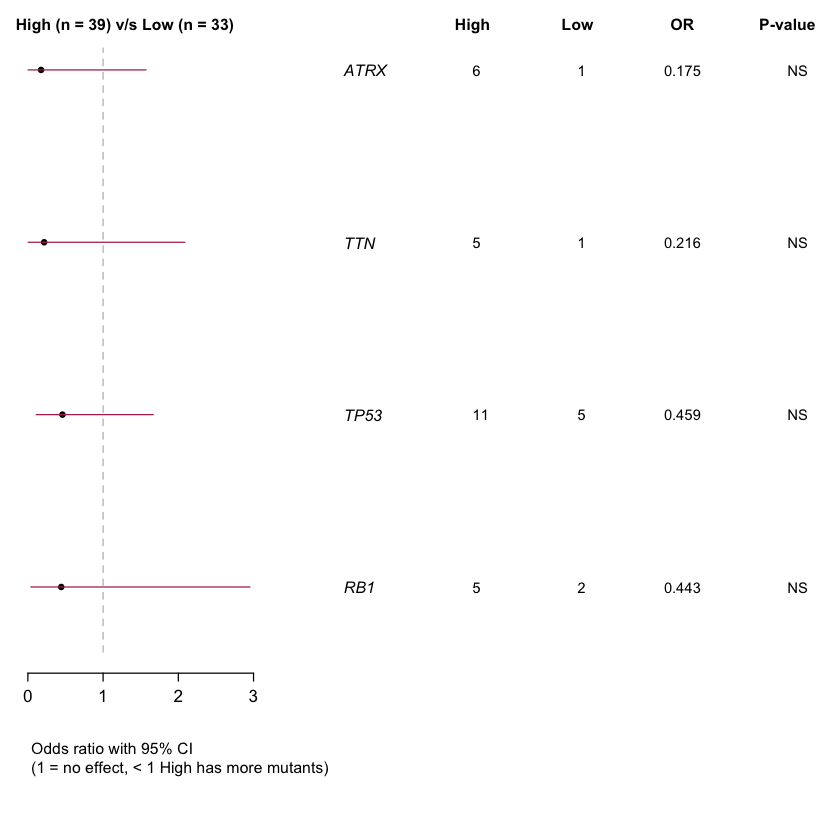

In [108]:
pt.vs.rt <- mafCompare(m1 = s1.maf, m2 = s2.maf, m1Name = 'Low', m2Name = 'High', minMut = 5)
forestPlot(mafCompareRes = pt.vs.rt, pVal = 1)#

### 转换颠倒统计

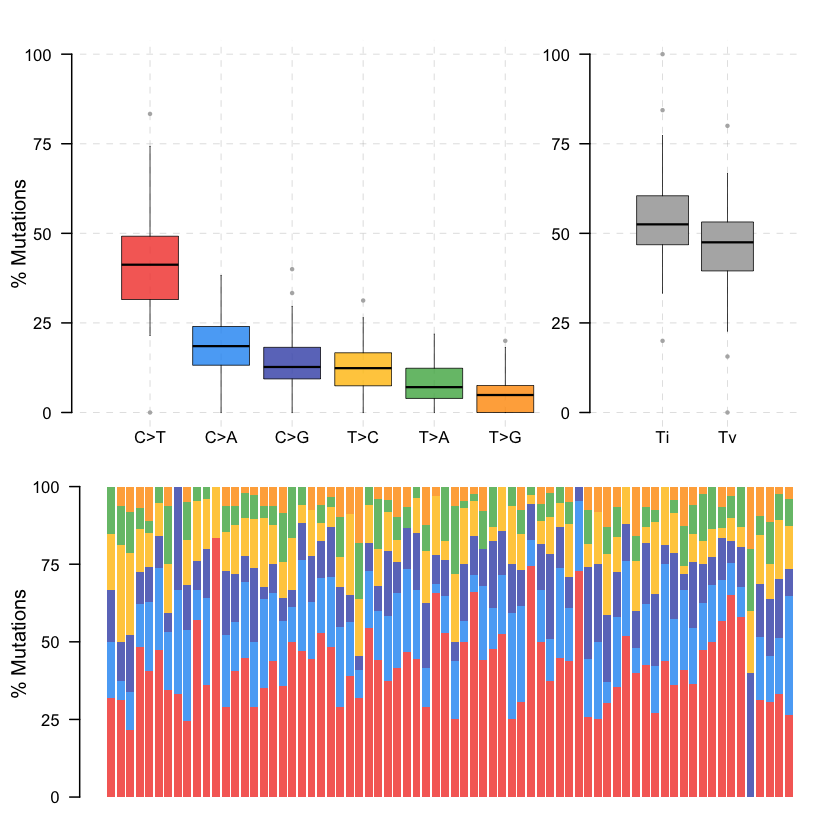

In [84]:
# Transition 转换 ： 嘌呤(AG)或嘧啶(CT)内部之间转换
# Transversions 颠倒：嘌呤与嘧啶间互相转换
maf_obj.titv = titv(maf = maf_obj, plot = FALSE, useSyn = TRUE)
plotTiTv(res = maf_obj.titv)

### 基因对突变统计

gene1,gene2,pValue,oddsRatio,00,01,11,10,pAdj,Event,pair,event_ratio
<chr>,<chr>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<dbl>,<chr>,<chr>,<chr>
LAMA2,ATRX,0.02347418,22.909665,64,5,2,1,0.4191818,Co_Occurence,"ATRX, LAMA2",2/6
MICAL3,ATRX,0.02347418,22.909665,64,5,2,1,0.4191818,Co_Occurence,"ATRX, MICAL3",2/6
MYH7,MUC16,0.02347418,22.909665,64,5,2,1,0.4191818,Co_Occurence,"MUC16, MYH7",2/6
MUC4,RB1,0.02347418,22.909665,64,5,2,1,0.4191818,Co_Occurence,"MUC4, RB1",2/6
PCDH15,RB1,0.02347418,22.909665,64,5,2,1,0.4191818,Co_Occurence,"PCDH15, RB1",2/6
MUC16,TP53,0.03912608,5.694212,53,12,4,3,0.6609135,Co_Occurence,"MUC16, TP53",4/15
TTN,RB1,0.10126039,5.840113,61,5,2,4,0.7553572,Co_Occurence,"RB1, TTN",2/9
MET,CSMD3,0.10876369,19.491322,67,3,1,1,0.7553572,Co_Occurence,"CSMD3, MET",1/4
MICAL3,ALMS1,0.12149564,14.876325,67,2,1,2,0.7553572,Co_Occurence,"ALMS1, MICAL3",1/4


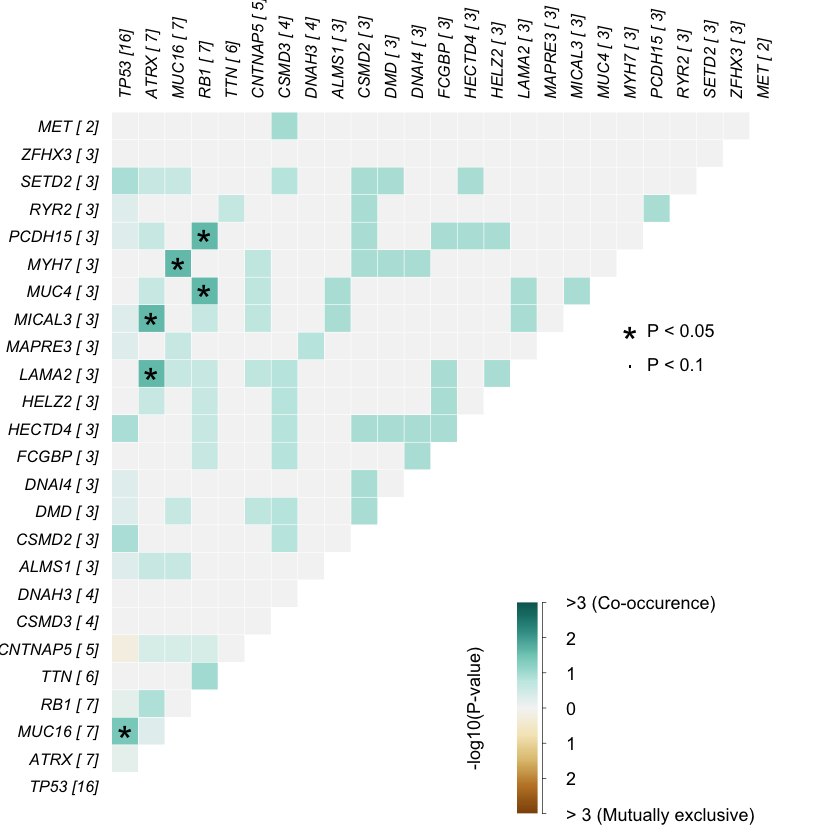

gene1,gene2,pValue,oddsRatio,00,01,11,10,pAdj,Event,pair,event_ratio
<chr>,<chr>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<dbl>,<chr>,<chr>,<chr>
ATRX,ABCG1,0.008215962,Inf,65,0,2,5,0.2225783,Co_Occurence,"ABCG1, ATRX",2/5
DENND5A,ABCA5,0.013888889,Inf,71,0,1,0,0.2225783,Co_Occurence,"ABCA5, DENND5A",1/0
COL16A1,ADAMTS10,0.013888889,Inf,71,0,1,0,0.2225783,Co_Occurence,"ADAMTS10, COL16A1",1/0
LOXHD1,GKN1,0.013888889,Inf,71,0,1,0,0.2225783,Co_Occurence,"GKN1, LOXHD1",1/0
PTGS1,GKN1,0.013888889,Inf,71,0,1,0,0.2225783,Co_Occurence,"GKN1, PTGS1",1/0
TMEM155,HIRIP3,0.013888889,Inf,71,0,1,0,0.2225783,Co_Occurence,"HIRIP3, TMEM155",1/0
PTGS1,LOXHD1,0.013888889,Inf,71,0,1,0,0.2225783,Co_Occurence,"LOXHD1, PTGS1",1/0
ABCG1,ABCA5,0.027777778,Inf,70,0,1,1,0.3543084,Co_Occurence,"ABCA5, ABCG1",1/1
ABCG1,CHD4,0.027777778,Inf,70,0,1,1,0.3543084,Co_Occurence,"ABCG1, CHD4",1/1


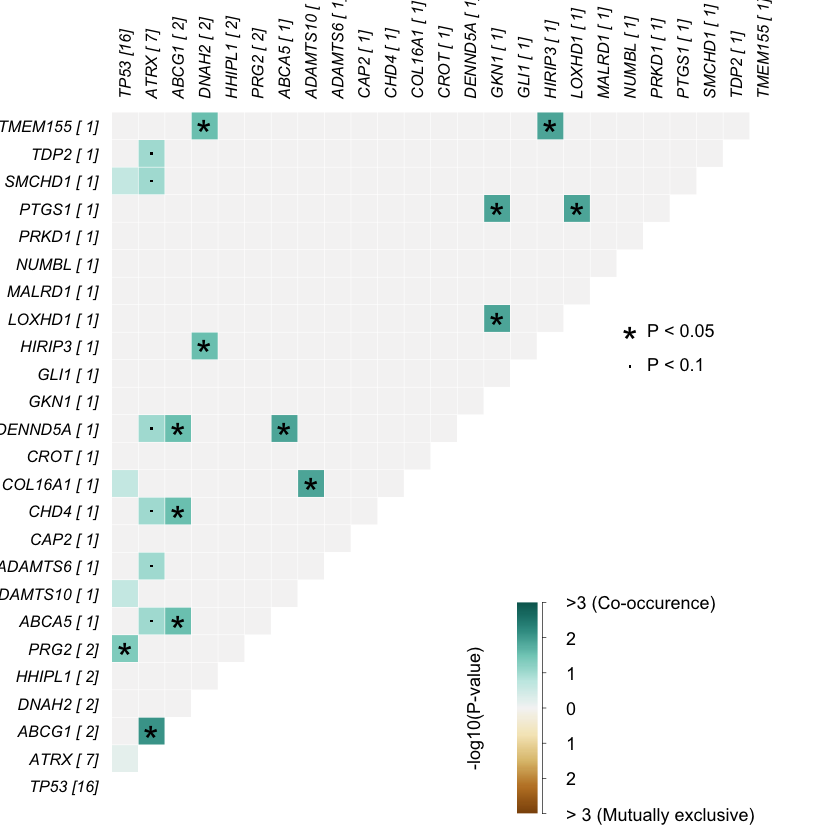

In [85]:
# green: co-occuring
# yellow: mutually exclusive

somaticInteractions(maf = maf_obj, top = 25, pvalue = c(0.05, 0.1))

set.seed(42)
genes = sample(maf_obj@data$Hugo_Symbol,25)
somaticInteractions(maf = maf_obj, genes  = genes , pvalue = c(0.05, 0.1))

### 生存分析

In [87]:
mafSurvival(maf = maf_obj, genes = 'TP53', 
			time = 'days', Status = 'vital_status')
#     Group medianTime  N
# 1: Mutant        732  4
# 2:     WT        650 41


Looking for clinical data in annoatation slot of MAF..

Number of mutated samples for given genes: 



TP53 
  16 


Removed 72 samples with NA's

Median survival..



Empty data.table (0 rows and 3 cols): Group,medianTime,N


Warning message in max(event[who2]):
"no non-missing arguments to max; returning -Inf"


ERROR: Error in survfit.formula(formula = survival::Surv(time = Time, event = Status) ~ : data set has no non-missing observations


In [ ]:
## 提取信息
# maf_obj@clinical.data %>% 
# 	dplyr::mutate(Group=ifelse(Tumor_Sample_Barcode %in% 
# 		subset(maf_obj@data, Hugo_Symbol=="TP53")$Barcode,
# 		"Mutant","WT")) 


In [ ]:
save(maf_obj,file = paste0("./2-Output/",project,"_maf.rda"))